In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel
from sklearn.metrics import r2_score, mean_squared_error

SEED=100
# from sklearn.pipeline import Pipeline
# from sklearn.model_selection import GridSearchCV, LeaveOneOut, cross_val_score, cross_val_predict
# from sklearn.metrics import mean_squared_error, r2_score

In [70]:
df = pd.read_excel('./datasets/swatch.xlsx')
df

,Sample,평량(g/m2),BET(m2/g),SWATCH(GD) 24h(Con),SWATCH(HD) 24h(Con)
0,ACF25-01,105.20,1150,320,280
1,ACF25-02,99.30,1450,470,220
2,ACF25-03,119.70,1150,1150,550
3,ACF25-04,110.40,1300,850,850
4,ACF25-05,103.44,1016,470,580
5,ACF25-06,122.83,1080,20,140
6,ACF25-07,154.49,1139,380,10
7,ACF25-08,140.00,1300,20,5
8,ACF25-09,130.00,2197,50,5


In [71]:
cols = df.columns
cols_GD = df.columns[3]
cols_HD = df.columns[4]

print(cols)
print(cols_GD)
print(cols_HD)

Index(['Sample', '평량(g/m2)', 'BET(m2/g)', 'SWATCH(GD) 24h(Con)',
       'SWATCH(HD) 24h(Con)'],
      dtype='object')
SWATCH(GD) 24h(Con)
SWATCH(HD) 24h(Con)


In [72]:
X = df[[cols[1], cols[2]]]
y = df[cols_GD]
y

0     320
1     470
2    1150
3     850
4     470
5      20
6     380
7      20
8      50
Name: SWATCH(GD) 24h(Con), dtype: int64

# Gaussian Process Regression

In [73]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[-0.88748493, -0.47116863],
       [-1.22759354,  0.41720798],
       [-0.05162477, -0.47116863],
       [-0.58772818, -0.02698033],
       [-0.98894106, -0.86797685],
       [ 0.12880573, -0.67845651],
       [ 1.95386314, -0.50374244],
       [ 1.11857944, -0.02698033],
       [ 0.54212416,  2.62926575]])

In [74]:
kernel = ConstantKernel(1.0) * RBF([1.0, 1.0]) + WhiteKernel(noise_level=1.0)
kernel

1**2 * RBF(length_scale=[1, 1]) + WhiteKernel(noise_level=1)

In [81]:
# GPR 모델 생성 및 학습
gpr_model = GaussianProcessRegressor(kernel = kernel, n_restarts_optimizer=20, random_state=SEED)
res = gpr_model.fit(X_scaled, y)

c:\Programming\Anaconda\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Programming\Anaconda\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


In [87]:
lml = res.log_marginal_likelihood_value_

length_scales = res.kernel_.k1.k2.length_scale
length_scales

relevance = (1.0 / length_scales) / (1.0 / length_scales).sum() * 100  # 기여도 %
relevance

array([71.30337088, 28.69662912])

In [93]:
def fit_gpr_reduced(X_sc, y, n_restarts=20, seed=42):
    """1D ARD GPR 적합 (특성 1개 제거된 데이터)."""
    kernel = (
        ConstantKernel(1.0)
        * RBF(length_scale=1.0)
        + WhiteKernel(noise_level=1.0,)
    )
    gpr = GaussianProcessRegressor(
        kernel=kernel,
        n_restarts_optimizer=n_restarts,
        random_state=seed
    )
    gpr.fit(X_sc, y)
    return gpr

In [95]:
feat_names = [cols[1], cols[2]]

rows = []
for i, fname in enumerate(feat_names):
    idx = [j for j in range(len(feat_names)) if j != i]
    gpr_red = fit_gpr_reduced(X_scaled[:, idx], y)
    lml_red = gpr_red.log_marginal_likelihood_value_
    delta   = lml - lml_red

    if delta >= 3:
        sig = '*** (유의)'
    elif delta >= 1:
        sig = '*   (경계)'
    else:
        sig = '    (비유의)'

    rows.append({
        '특성':            fname,
        'ARD length scale': round(length_scales[i], 4),
        '기여도 (%)':       round(relevance[i], 2),
        'logLML (전체)':    round(lml, 4),
        'logLML (제거 후)': round(lml_red, 4),
        'ΔlogLML':         round(delta, 4),
        '유의성':           sig
    })
pd.DataFrame(rows)

c:\Programming\Anaconda\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Programming\Anaconda\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Programming\Anaconda\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Programming\Anaconda\Lib\site-packages\sklearn\gaussian_process\kern

,특성,ARD length scale,기여도 (%),logLML (전체),logLML (제거 후),ΔlogLML,유의성
0,평량(g/m2),0.7381,71.3,-603.8124,-67.7617,-536.0507,(비유의)
1,BET(m2/g),1.8340,28.7,-603.8124,-67.9580,-535.8545,(비유의)


In [78]:
print("--- GPR ARD 분석 결과 (변수 중요도) ---")
features = ['weight', 'BET']
for feature, ls in zip(features, length_scales):
    print(f"변수: {feature:10s} | 최적화된 길이 척도(Length Scale): {ls:.4f}")

print("\n[해석 지침]")
print("- 길이 척도 값이 작을수록: 해당 변수가 조금만 변해도 Y가 민감하게 반응함 (중요/유의)")
print("- 길이 척도 값이 클수록: 해당 변수가 변해도 Y에 영향이 적음 (무시 가능/유의성 낮음)")

--- GPR ARD 분석 결과 (변수 중요도) ---
변수: weight     | 최적화된 길이 척도(Length Scale): 100000.0000
변수: BET        | 최적화된 길이 척도(Length Scale): 8188.3599

[해석 지침]
- 길이 척도 값이 작을수록: 해당 변수가 조금만 변해도 Y가 민감하게 반응함 (중요/유의)
- 길이 척도 값이 클수록: 해당 변수가 변해도 Y에 영향이 적음 (무시 가능/유의성 낮음)


c:\Programming\Anaconda\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Programming\Anaconda\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Train R²: 0.7934933110653486
Train RMSE: 165.31251735852098
Optimized kernel:
0.739**2 * RBF(length_scale=[0.01, 0.01]) + WhiteKernel(noise_level=0.454)


c:\Programming\Anaconda\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Programming\Anaconda\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Programming\Anaconda\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Programming\Anaconda\Lib\site-packages\sklearn\gaussian_process\kernels.py:44

LOOCV R²: -0.7020818442039951
LOOCV RMSE: 474.60127130137596


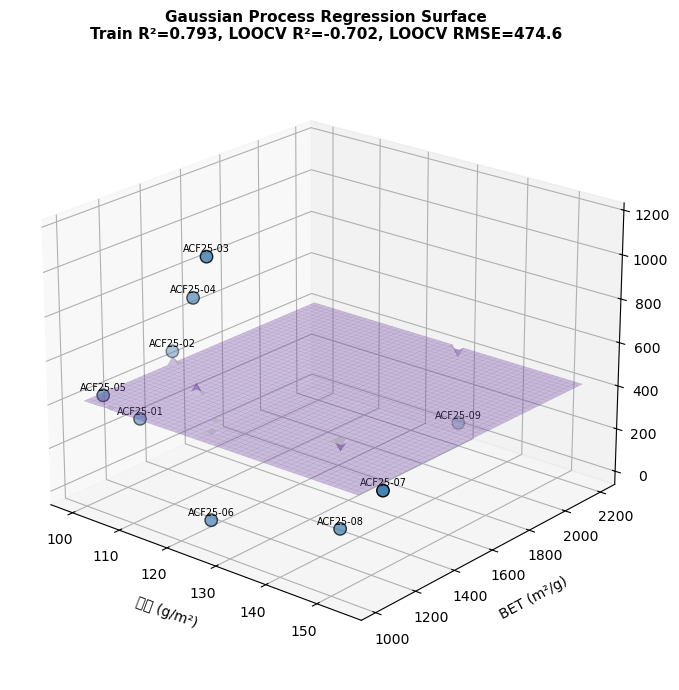

In [79]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.model_selection import LeaveOneOut, cross_val_predict

# -----------------------------
# 1. 데이터 설정
# -----------------------------
x1_col = '평량(g/m2)'
x2_col = 'BET(m2/g)'
y_col  = 'SWATCH(GD) 24h(Con)'   # HD는 'SWATCH(HD) 24h(Con)'로 변경

X = df[[x1_col, x2_col]].values
y = df[y_col].values

# -----------------------------
# 2. GPR 모델 정의
# -----------------------------
kernel = (
    ConstantKernel(1.0, (1e-3, 1e3))
    * RBF(length_scale=[1.0, 1.0], length_scale_bounds=(1e-2, 1e3))
    + WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-5, 1e3))
)

gpr_model = Pipeline([
    ('scaler', StandardScaler()),
    ('gpr', GaussianProcessRegressor(
        kernel=kernel,
        n_restarts_optimizer=20,
        normalize_y=True,
        random_state=42
    ))
])

# -----------------------------
# 3. 모델 학습
# -----------------------------
gpr_model.fit(X, y)

y_pred = gpr_model.predict(X)

r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print("Train R²:", r2)
print("Train RMSE:", rmse)
print("Optimized kernel:")
print(gpr_model.named_steps['gpr'].kernel_)

# -----------------------------
# 4. LOOCV 예측 성능
# -----------------------------
loo = LeaveOneOut()

loo_pred = cross_val_predict(gpr_model, X, y, cv=loo)

loo_r2 = r2_score(y, loo_pred)
loo_rmse = np.sqrt(mean_squared_error(y, loo_pred))

print("LOOCV R²:", loo_r2)
print("LOOCV RMSE:", loo_rmse)

# -----------------------------
# 5. 3D 예측 grid 생성
# -----------------------------
x1_grid = np.linspace(X[:, 0].min(), X[:, 0].max(), 50)
x2_grid = np.linspace(X[:, 1].min(), X[:, 1].max(), 50)

X1g, X2g = np.meshgrid(x1_grid, x2_grid)
X_grid = np.column_stack([X1g.ravel(), X2g.ravel()])

# GPR 예측값 + 표준편차
y_grid_pred, y_grid_std = gpr_model.predict(X_grid, return_std=True)

Z_pred = y_grid_pred.reshape(X1g.shape)
Z_std  = y_grid_std.reshape(X1g.shape)

# -----------------------------
# 6. 3D GPR 예측 곡면
# -----------------------------
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# GPR 예측 곡면
ax.plot_surface(
    X1g, X2g, Z_pred,
    alpha=0.35,
    color='mediumpurple',
    edgecolor='none'
)

ax.plot_wireframe(
    X1g, X2g, Z_pred,
    alpha=0.20,
    color='purple',
    linewidth=0.3
)

# 실제 관측점
ax.scatter(
    X[:, 0], X[:, 1], y,
    color='steelblue',
    edgecolors='black',
    s=80,
    depthshade=True,
    label='Observed'
)

# 샘플명 표시
for _, row in df.iterrows():
    ax.text(
        row[x1_col],
        row[x2_col],
        row[y_col] + 20,
        row['Sample'],
        fontsize=7,
        ha='center'
    )

ax.set_xlabel('평량 (g/m²)', labelpad=8)
ax.set_ylabel('BET (m²/g)', labelpad=8)
ax.set_zlabel(y_col, labelpad=8)

ax.set_title(
    f'Gaussian Process Regression Surface\n'
    f'Train R²={r2:.3f}, LOOCV R²={loo_r2:.3f}, LOOCV RMSE={loo_rmse:.1f}',
    fontsize=11,
    fontweight='bold'
)

ax.view_init(elev=22, azim=-50)

plt.tight_layout()
plt.show()

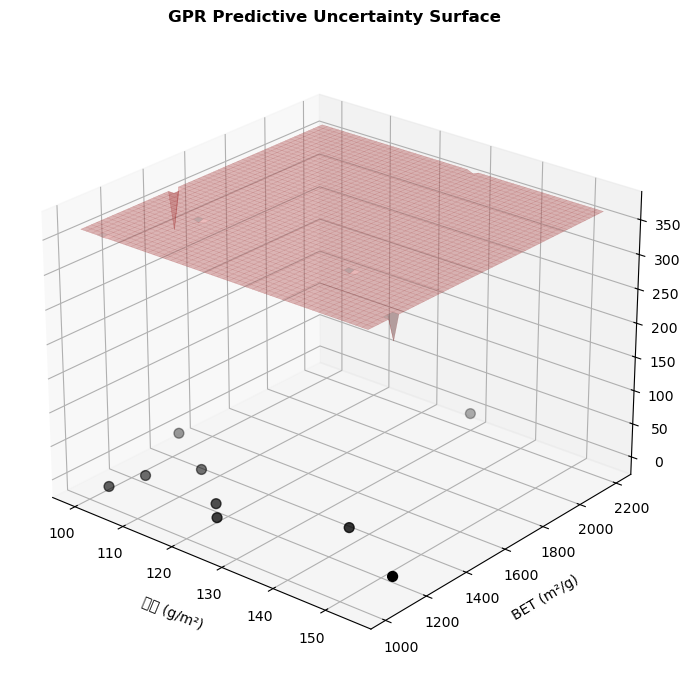

In [80]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(
    X1g, X2g, Z_std,
    alpha=0.45,
    color='lightcoral',
    edgecolor='none'
)

ax.plot_wireframe(
    X1g, X2g, Z_std,
    alpha=0.25,
    color='darkred',
    linewidth=0.3
)

ax.scatter(
    X[:, 0], X[:, 1], np.zeros_like(y),
    color='black',
    s=50,
    label='Observed locations'
)

ax.set_xlabel('평량 (g/m²)', labelpad=8)
ax.set_ylabel('BET (m²/g)', labelpad=8)
ax.set_zlabel('Predictive Std', labelpad=8)

ax.set_title('GPR Predictive Uncertainty Surface', fontsize=12, fontweight='bold')
ax.view_init(elev=25, azim=-50)

plt.tight_layout()
plt.show()